<a href="https://colab.research.google.com/github/kristinacparadise-2013/Asthma_Hospitalizations_by_Average_AQI_Analysis/blob/main/Asthma_hospitalizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import sqlite3

asthma = pd.read_csv("/content/sample_data/asthma/asthma_hospitalization_by_county.csv")
aqi_2021 = pd.read_csv("/content/sample_data/asthma/annual_aqi_by_county_2021.csv")
aqi_2022 = pd.read_csv("/content/sample_data/asthma/annual_aqi_by_county_2022.csv")
aqi_2023 = pd.read_csv("/content/sample_data/asthma/annual_aqi_by_county_2023.csv")

In [9]:
conn = sqlite3.connect("biostat_project.db")

asthma.to_sql("asthma", conn, if_exists="replace", index=False)
aqi_2021.to_sql("aqi_2021", conn, if_exists="replace", index=False)
aqi_2022.to_sql("aqi_2022", conn, if_exists="replace", index=False)
aqi_2023.to_sql("aqi_2023", conn, if_exists="replace", index=False)

992

In [10]:
query = """
SELECT * FROM aqi_2021
UNION ALL
SELECT * FROM aqi_2022
UNION ALL
SELECT * FROM aqi_2023
"""

aqi_combined = pd.read_sql(query, conn)

aqi_combined.to_sql("aqi_combined", conn, if_exists="replace", index=False)

3000

In [15]:
query = """
SELECT
a.state,
a.county,
a.year,
AVG(a.value) AS asthma_rate,
AVG(p."MAX AQI") AS avg_aqi
FROM asthma a
JOIN aqi_combined p
ON a.state = p.state
AND a.county = p.county
AND a.year = p.year
GROUP BY a.state, a.county, a.year
"""

df = pd.read_sql(query, conn)

In [16]:
display(df.head())

,State,County,Year,asthma_rate,avg_aqi
0,Arizona,Apache,2021,11.0,90.0
1,Arizona,Apache,2022,10.0,57.0
2,Arizona,Apache,2023,12.0,106.0
3,Arizona,Cochise,2021,38.0,105.0
4,Arizona,Cochise,2022,56.0,101.0


In [18]:
df = df.dropna()

df["asthma_rate"] = pd.to_numeric(df["asthma_rate"])
df["avg_aqi"] = pd.to_numeric(df["avg_aqi"])



In [19]:
from scipy.stats import pearsonr

corr, p = pearsonr(df["avg_aqi"], df["asthma_rate"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.04545302197763251
P-value: 0.08402250534639083


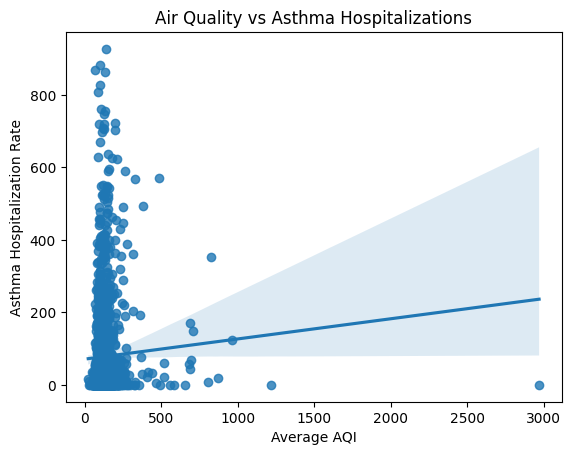

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df, x="avg_aqi", y="asthma_rate")

plt.title("Air Quality vs Asthma Hospitalizations")
plt.xlabel("Average AQI")
plt.ylabel("Asthma Hospitalization Rate")

plt.show()